# Amazon-Tocantins Release Region

Map of the Amazon-Tocantins river mouth complex.

The Coles-style lat/lon box turned out to be **36% land** - it swallows eastern Marajo
and part of the Para mainland. The replacement is a **band along the mouth axis**:

- **left edge**  - the old release line, prolonged SE until it strikes the Para bank,
  so the southern tip rests on the coast just as the northern tip rests on the Amazon coast
- **right edge** - that edge pushed 0.8 deg seaward, perpendicular to the axis

This keeps the Tocantins/Para mouth properly represented instead of clipping it short
in open water.

In [15]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from shapely.geometry import Polygon, box as sbox
from shapely.ops import unary_union

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore', category=RuntimeWarning)

## 1. Release geometry

In [35]:
# --- OLD: release line ---
old_lons = [-49.916, -49.083]
old_lats = [1.166, -0.083]

# --- Coles-style box (kept for comparison) ---
LON_W, LON_E = -50.0, -48.2
LAT_S, LAT_N = -0.75, 0.85
polygon_lons = [LON_W, LON_E, LON_E, LON_W, LON_W]
polygon_lats = [LAT_S, LAT_S, LAT_N, LAT_N, LAT_S]

# --- NEW: green release band ---
#   A  Amazon coast  - start of the old release line
#   B  Para coast    - old line prolonged SE until it strikes the Para bank
#   B' seaward corner off B  (pushed NE, not perpendicular: the Maranhao coast
#                             bends east, so a perpendicular corner runs aground)
#   A' seaward corner off A  (0.8 deg perpendicular)
green_lons = [-49.916, -48.392, -47.8, -49.250, -49.916]
green_lats = [  1.166,  -1.05,  -0.6,   1.610,    1.166]

## 2. Map

`cfeature.RIVERS` and the Natural Earth coastline are downloaded on first use
(cached under `~/.local/share/cartopy`).

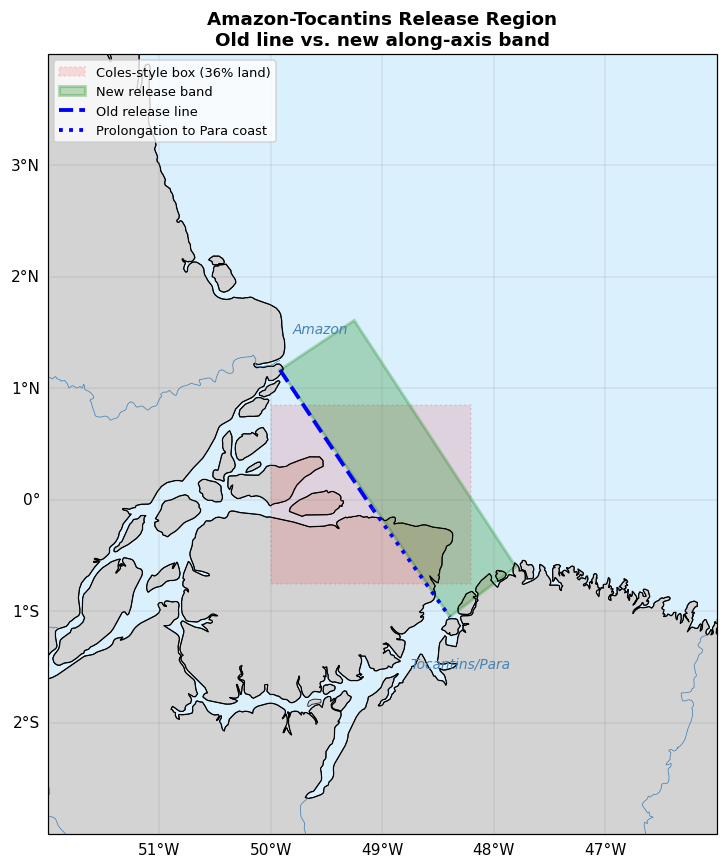

Saved: release_polygon_map.png


In [36]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([-52, -46, -3, 4], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='lightskyblue', alpha=0.3)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='steelblue')

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Coles-style box (rejected: too much land)
ax.fill(polygon_lons, polygon_lats, transform=ccrs.PlateCarree(),
        facecolor='red', alpha=0.12, edgecolor='red', linewidth=1.2,
        linestyle=':', label='Coles-style box (36% land)')

# New green band
ax.fill(green_lons, green_lats, transform=ccrs.PlateCarree(),
        facecolor='green', alpha=0.25, edgecolor='green', linewidth=2,
        label='New release band')

# Old release line
ax.plot(old_lons, old_lats, transform=ccrs.PlateCarree(),
        color='blue', linewidth=2.5, linestyle='--', label='Old release line')

# The prolongation, drawn dotted so the extension is visible
ax.plot([old_lons[1], green_lons[1]], [old_lats[1], green_lats[1]], transform=ccrs.PlateCarree(),
        color='blue', linewidth=2.5, linestyle=':', label='Prolongation to Para coast')

ax.text(-49.8, 1.5, 'Amazon', fontsize=9, fontstyle='italic',
        transform=ccrs.PlateCarree(), color='steelblue')
ax.text(-48.75, -1.5, 'Tocantins/Para', fontsize=9, fontstyle='italic',
        transform=ccrs.PlateCarree(), color='steelblue')

ax.legend(loc='upper left', fontsize=8.5)
ax.set_title('Amazon-Tocantins Release Region\nOld line vs. new along-axis band',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('release_polygon_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: release_polygon_map.png")

## 3. Bathymetry

Natural Earth ocean-depth polygons give coarse bathymetric bands (shallow shelf = light,
deep ocean = dark). They are a separate download, so this cell falls back to a flat ocean
fill if unavailable.

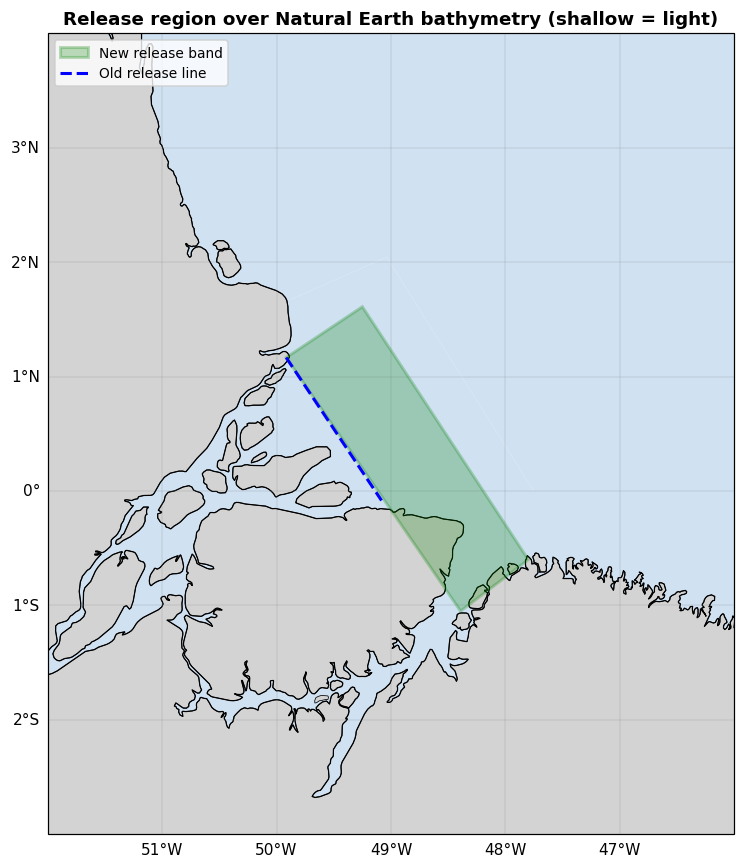

In [37]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([-52, -46, -3, 4], crs=ccrs.PlateCarree())

# Natural Earth bathymetry layers, deepest first (letter codes are NE's own naming)
bath_layers = [('G', 4000), ('H', 3000), ('I', 2000), ('J', 1000), ('K', 200), ('L', 0)]
try:
    shades = plt.cm.Blues_r(np.linspace(0.15, 0.8, len(bath_layers)))
    for (letter, depth), c in zip(bath_layers, shades):
        feat = cfeature.NaturalEarthFeature('physical', f'bathymetry_{letter}_{depth}', '10m')
        ax.add_feature(feat, facecolor=c, edgecolor='none', zorder=0)
except Exception as e:            # offline / feature unavailable
    print(f"Bathymetry unavailable ({e}); plotting flat ocean instead.")
    ax.add_feature(cfeature.OCEAN, facecolor='lightskyblue', alpha=0.3, zorder=0)

ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.fill(green_lons, green_lats, transform=ccrs.PlateCarree(),
        facecolor='green', alpha=0.25, edgecolor='green', linewidth=2, zorder=3,
        label='New release band')
ax.plot(old_lons, old_lats, transform=ccrs.PlateCarree(),
        color='blue', linewidth=2, linestyle='--', zorder=3, label='Old release line')

ax.legend(loc='upper left', fontsize=9)
ax.set_title('Release region over Natural Earth bathymetry (shallow = light)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('release_polygon_bathymetry.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Land contamination: box vs. band

The Coles-style box swallows eastern Marajo and a strip of the Para mainland. The band
follows the mouth axis instead, so it keeps the same usable water area with far less land.
Land fractions below come from the Natural Earth 10 m land polygons (a coastline
approximation - section 6 repeats the test against the GLORYS12 mask, which is what
actually governs where particles can sit).

In [19]:
land = unary_union([g.geometry for g in shpreader.Reader(
    shpreader.natural_earth('10m', 'physical', 'land')).records()])

regions = {'Coles-style box': sbox(LON_W, LAT_S, LON_E, LAT_N),
           'New green band' : Polygon(zip(green_lons[:-1], green_lats[:-1]))}

print(f"{'region':18s} {'area':>8s} {'land %':>8s} {'water area':>11s}")
print("-" * 48)
for nm, poly in regions.items():
    land_area = poly.intersection(land).area
    print(f"{nm:18s} {poly.area:8.3f} {100*land_area/poly.area:7.1f}% "
          f"{poly.area - land_area:10.3f}")
print("\n(areas in square degrees)")

region                 area   land %  water area
------------------------------------------------
Coles-style box       2.880    36.1%      1.841
New green band        1.943    10.9%      1.730

(areas in square degrees)


## 5. GLORYS12 land-mask check

Some grid cells inside the polygon may be land. Point `GLORYS_FILE` at any GLORYS12
file (a mask, or any field with a `time`/`depth` slice) to overlay the model grid and
count wet vs. dry release cells. The cell no-ops if the file is not present.

In [20]:
from pathlib import Path
import xarray as xr

GLORYS_FILE = Path('glorys12_mask.nc')   # <-- edit to your GLORYS12 file
VARNAME     = None                        # None -> first 2-D-able variable

if not GLORYS_FILE.exists():
    print(f"{GLORYS_FILE} not found - skipping land-mask check.")
else:
    ds = xr.open_dataset(GLORYS_FILE)
    var = VARNAME or list(ds.data_vars)[0]
    da = ds[var]
    for d in ('time', 'depth'):
        if d in da.dims:
            da = da.isel({d: 0})

    lon_name = 'longitude' if 'longitude' in da.coords else 'lon'
    lat_name = 'latitude'  if 'latitude'  in da.coords else 'lat'
    bl, bs, br, bn = Polygon(zip(green_lons[:-1], green_lats[:-1])).bounds   # band bounding box
    sub = da.sel({lon_name: slice(bl, br), lat_name: slice(bs, bn)})

    wet = np.isfinite(sub.values).sum()
    tot = sub.size
    print(f"Variable '{var}': {wet}/{tot} cells wet ({100*wet/tot:.1f}%), {tot-wet} land cells")

    fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
    ax.set_extent([-52, -46, -3, 4], crs=ccrs.PlateCarree())
    da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), x=lon_name, y=lat_name,
                       cmap='Blues_r', add_colorbar=True, zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)

    # GLORYS grid lines inside the polygon
    for x in sub[lon_name].values:
        ax.plot([x, x], [bs, bn], transform=ccrs.PlateCarree(),
                color='k', lw=0.2, zorder=3)
    for y in sub[lat_name].values:
        ax.plot([bl, br], [y, y], transform=ccrs.PlateCarree(),
                color='k', lw=0.2, zorder=3)

    ax.plot(green_lons, green_lats, transform=ccrs.PlateCarree(),
            color='green', lw=2, zorder=4, label='Release band')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title('GLORYS12 grid around the release band', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('release_polygon_glorys_mask.png', dpi=200, bbox_inches='tight')
    plt.show()

glorys12_mask.nc not found - skipping land-mask check.


## Notes

- The band is a quadrilateral, not a lat/lon box, so seed particles by sampling inside the polygon (`shapely.contains`) rather than from a regular lon/lat mesh.
- Corner B' is pushed NE rather than straight perpendicular. The Maranhao coast turns east past the Para mouth, so the perpendicular corner (47.73 W, 0.68 S) sits on land; the NE corner keeps it in water and drops the band's land fraction to about 11%.
- The southern tip B rests on the Para bank at 1.12 S, mirroring the northern tip A on the Amazon coast, so the Tocantins/Para mouth is fully covered.
- Section 6 is the check that matters: the GLORYS12 mask, not the Natural Earth coastline, decides which cells are wet.